## Perform standard imports

In [ ]:
# Lightweight path setup for local Jupyter, VS Code, or Colab runs.
# It keeps the notebook runnable whether you start it from this folder or the repo root.
from pathlib import Path
import os

FOLDER_NAME = '12-Convolutional-Neural-Networks'
NOTEBOOK_NAME = 'Project_02_CNN_Custom Images.ipynb'

candidates = [
    Path.cwd(),
    Path.cwd() / FOLDER_NAME,
    Path.cwd() / "10-deep_learning" / FOLDER_NAME,
    Path.cwd().parent / FOLDER_NAME,
    Path.cwd().parent / "10-deep_learning" / FOLDER_NAME,
]

for candidate in candidates:
    if (candidate / NOTEBOOK_NAME).exists():
        os.chdir(candidate)
        break

print("Working directory:", Path.cwd().resolve())


In [3]:
! pip install split-folders

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
from torchsummary import summary
import splitfolders
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')

In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

## Define transforms

In [6]:
transform = transforms.Compose([transforms.ToTensor()])

## Prepare train and test sets, loaders

In [9]:
splitfolders.ratio("Circle_Cross", output="output",
    seed=1337, ratio=(.8, .2), group_prefix=None, move=False) # default values

Copying files: 2001 files [00:46, 42.90 files/s] 


In [10]:
train_data = datasets.ImageFolder('output/train', transform = transform)
test_data = datasets.ImageFolder('output/val', transform = transform)

In [11]:
train_loader = DataLoader(train_data, batch_size = 32, shuffle=True,  drop_last = True)
test_loader = DataLoader(test_data, batch_size= 32,  drop_last = True)

class_names = train_data.classes # classes or labels or categories

print(class_names)
print(f'Training images available: {len(train_data)}')
print(f'Testing images available:  {len(test_data)}')

['circles', 'crosses']
Training images available: 1599
Testing images available:  401


## Display a batch of images


In [12]:
for images,labels in train_loader:
    break
images.shape

torch.Size([32, 3, 116, 116])

In [13]:
labels

tensor([0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 1, 0, 0, 0])

Label: [0 1 0 1 1 0 1 0 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 0]
Class: circles crosses circles crosses crosses circles crosses circles circles circles circles crosses circles crosses circles crosses circles circles crosses circles circles crosses circles circles circles circles crosses crosses crosses circles circles circles


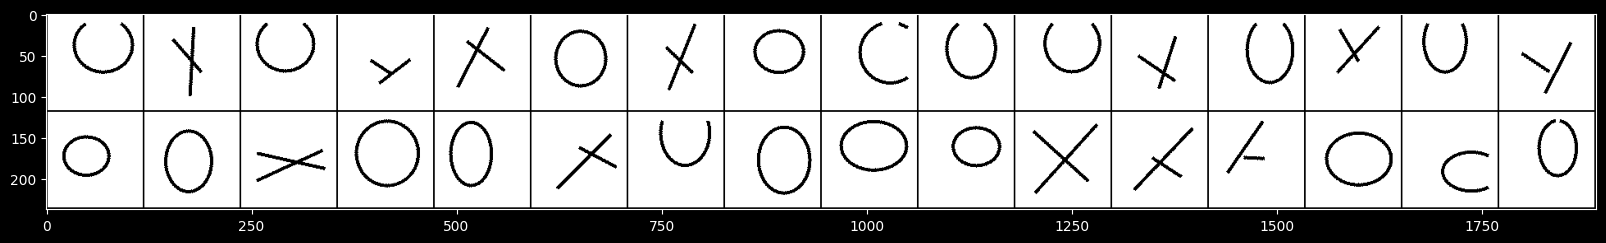

In [14]:
# Print the labels

print('Label:', labels.numpy())
print('Class:', *np.array([class_names[i] for i in labels]))

im = make_grid(images, nrow=16)  # 16 images in a row. the default nrow is 8

# Print the images

plt.figure(figsize=(20,16))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0))); # we see that dataloader has shuffle the images

##  Create CNN

In [15]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Defining Convolutional Layers

        self.conv1 = nn.Conv2d(3, 10, 5, 1, 1)
        # 3 = channel, 10 = number of kernels, 5 = kernel_size, 1 = Stride, 1 = padding
        self.conv2 = nn.Conv2d(10, 20, 5, 1, 1)

        # Definig Fully connected Layers

        #self.fc = nn.Linear(5*5*20, 64)
        self.fc = nn.LazyLinear(64)
        self.output = nn.Linear(64,2)

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        #X = X.view(-1, 5*5*20) # Infer the first dimension
        X = torch.flatten(X, 1) # Will be used with LazyLinear
        X = self.fc(X)
        X = F.relu(X)
        X = self.output(X)
        return X

In [16]:
model = CNN()
model

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


CNN(
  (conv1): Conv2d(3, 10, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (fc): LazyLinear(in_features=0, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=2, bias=True)
)

In [17]:
# count the total number of parameters in the model
summary(model.cuda(),(3,116,116))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 10, 114, 114]             760
            Conv2d-2           [-1, 20, 55, 55]           5,020
            Linear-3                   [-1, 64]         933,184
            Linear-4                    [-1, 2]             130
Total params: 939,094
Trainable params: 939,094
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.15
Forward/backward pass size (MB): 1.45
Params size (MB): 3.58
Estimated Total Size (MB): 5.19
----------------------------------------------------------------


# Training and Testing the model

In [18]:
epochs = 41

# loss function

lossfunc = nn.CrossEntropyLoss()

# optimizer

optimizer = torch.optim.SGD(model.parameters(), momentum = 0.9, lr = 0.01)

model.to(device) # placing a model on GPU

  # Initialize losses and Accuracies

losses    = torch.zeros(epochs)
trainAcc  = []
testAcc   = []


# loop over epochs

for epoch in range(epochs):
 model.train()

 # loop over training data batches

 batchAcc  = []
 batchLoss = []
 for X,y in train_loader:

  X = X.to(device) # Placing features on device
  y = y.to(device) # placing labels on device

  ypred = model(X)
  loss = lossfunc(ypred,y)


  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Append batchloss

  batchLoss.append(loss.item())

  ypred = ypred.cpu() # Back to cpu
  y = y.cpu()

  # compute batch accuracy

  acc = 100 * torch.mean((torch.argmax(ypred, dim=1) == y).float())
  batchAcc.append(acc)
# Batch loop concluded

# Average training accuracy (Outside the batchloop)

 trainAcc.append(np.mean(batchAcc))

# Losses through epochs

 losses[epoch] = np.mean(batchLoss)

# TESTING the model

 model.eval()
 X,y = next(iter(test_loader))
 X = X.to(device)
 y = y.to(device)

 with torch.no_grad(): #This step  Deactivating autogradient
  ypred = model(X)
  ypred = ypred.cpu()
  y = y.cpu()

 # Appending test accuracy

  testAcc.append(100 * torch.mean((torch.argmax(ypred,dim=1)==y).float()))
  if (epoch % 10) == 0:

        print(f' epochs : {epoch}  loss : {loss : 2.2f}')



 epochs : 0  loss :  0.58
 epochs : 10  loss :  0.00
 epochs : 20  loss :  0.00
 epochs : 30  loss :  0.00
 epochs : 40  loss :  0.00


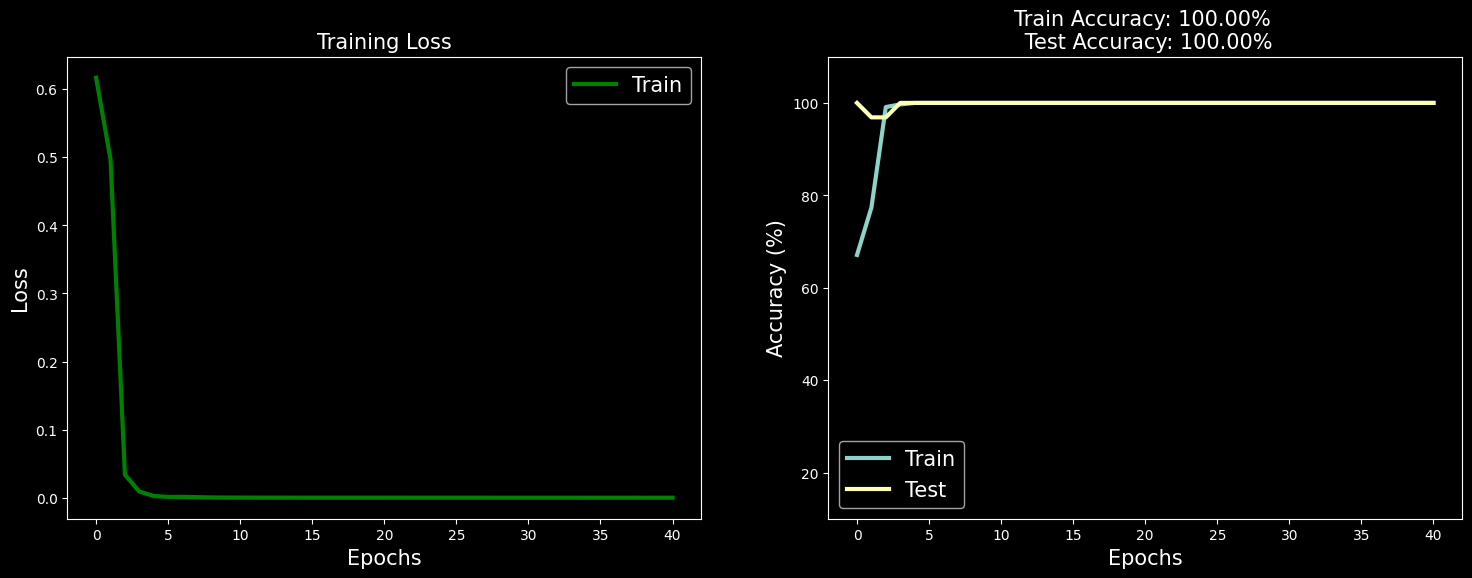

In [19]:
fig,ax = plt.subplots(1,2,figsize=(18,6))

ax[0].plot(losses, 'g', lw = 3, label = 'Train')
ax[0].set_xlabel('Epochs', fontsize = 15)
ax[0].set_ylabel('Loss', fontsize = 15)
ax[0].legend(fontsize = 15)
ax[0].set_title('Training Loss', fontsize = 15)

ax[1].plot(trainAcc, label ='Train', lw = 3)
ax[1].plot(testAcc, label ='Test', lw = 3)
ax[1].set_xlabel('Epochs', fontsize = 15)
ax[1].set_ylabel('Accuracy (%)', fontsize = 15)
ax[1].set_ylim([10,110])
ax[1].set_title(f'Train Accuracy: {trainAcc[-1]:.2f}% \n Test Accuracy: {testAcc[-1]:.2f}%', fontsize = 15)
ax[1].legend(fontsize = 15)

plt.show()